In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json


#  Data Loading
df = pd.read_csv("your_data.csv")

# remove useless column
df = df.drop(columns=["Unnamed: 0"])

df.head()

,fasting blood sugar,age,triglyceride,systolic,relaxation,ALT,HDL,eyesight(left),weight(kg),AST,smoking
0,94,55,300,135,87,25,40,0.5,60,22,1
1,147,70,55,146,83,23,57,0.6,65,27,0
2,79,20,197,118,75,31,45,0.4,75,27,1
3,91,35,203,131,88,27,38,1.5,95,20,0
4,91,30,87,121,76,13,44,1.5,60,19,1


### Univariate Analysis
We analyze each feature individually to understand its distribution. 
This helps identify skewness, spread, and general behavior of each variable in the dataset.

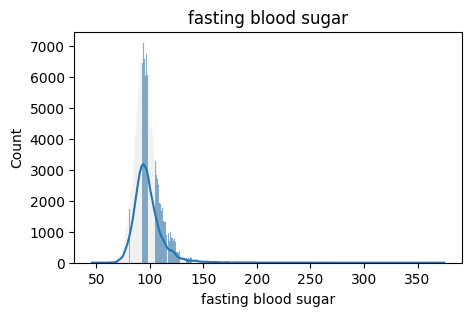

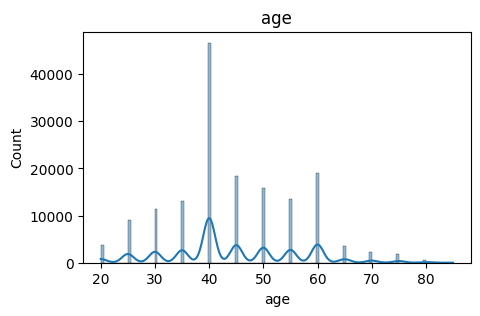

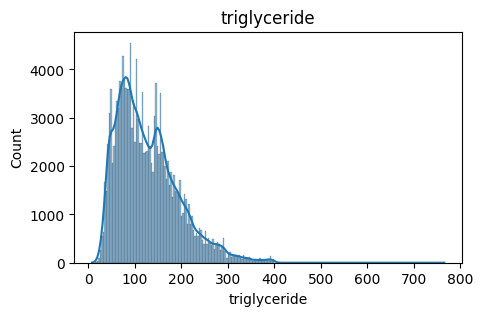

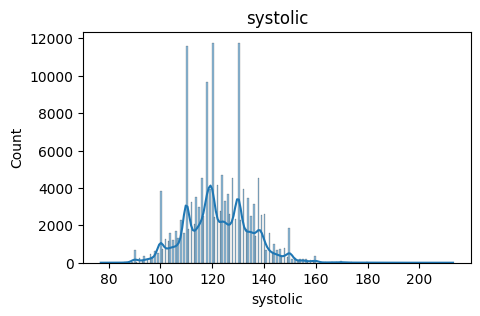

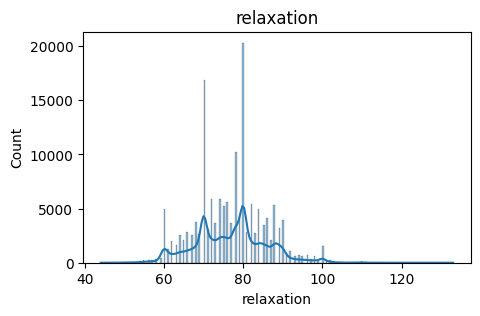

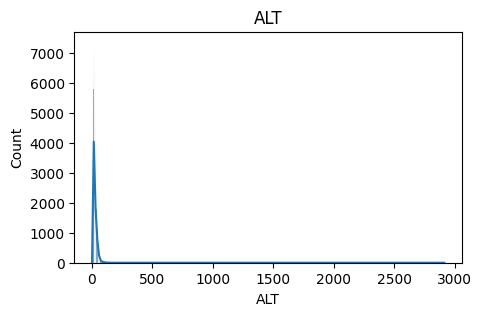

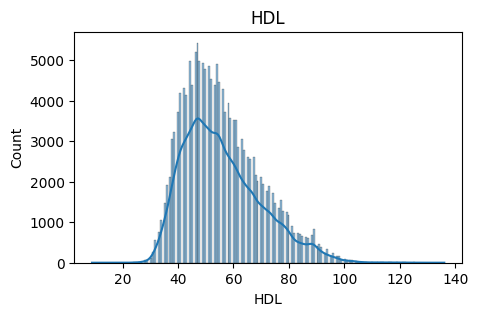

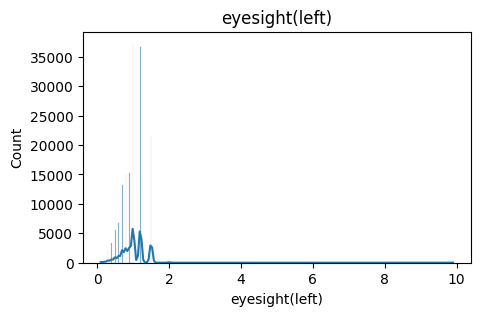

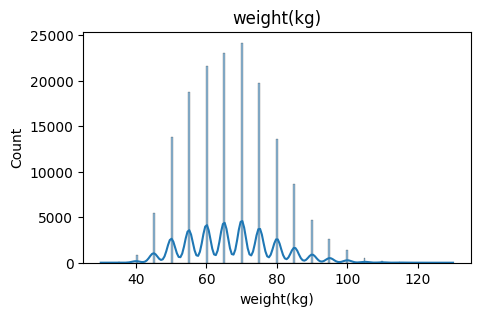

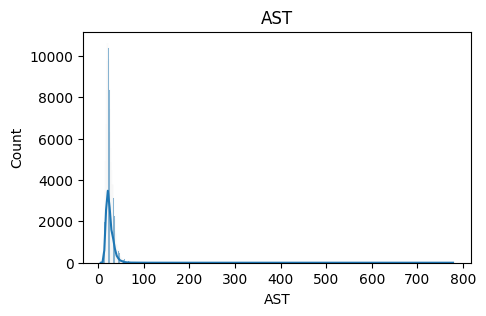

In [6]:
for col in df.columns:
    if col != "smoking":
        plt.figure(figsize=(5,3))
        sns.histplot(df[col], kde=True)
        plt.title(col)
        plt.show()

### Outlier Detection
Boxplots are used to detect outliers in each feature. 
Outliers are extreme values that may affect model performance and need to be handled during preprocessing.

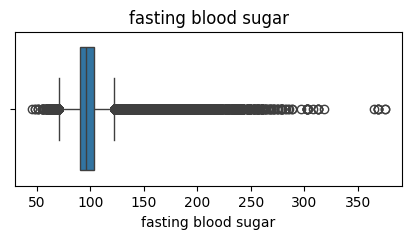

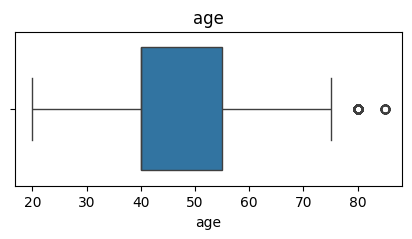

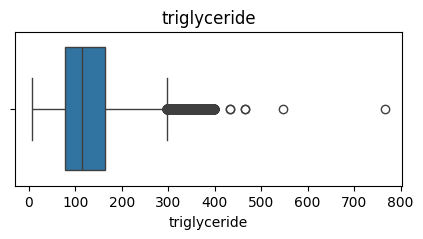

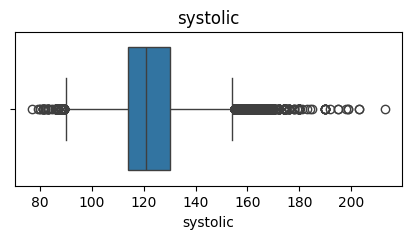

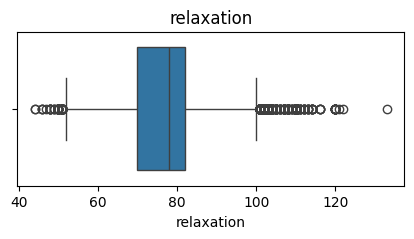

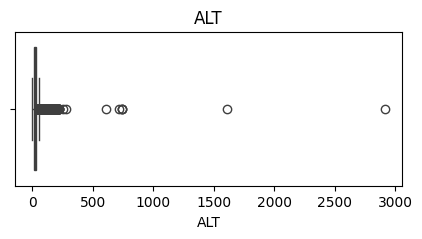

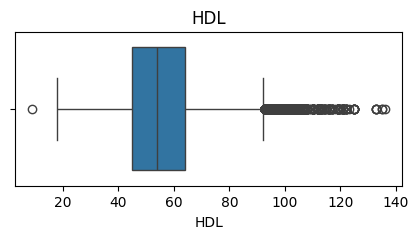

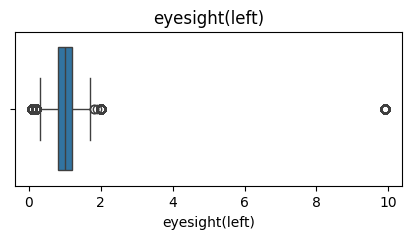

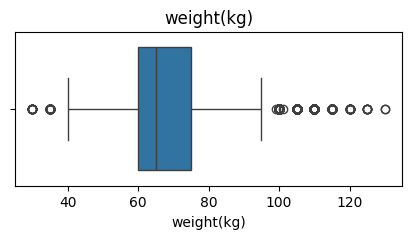

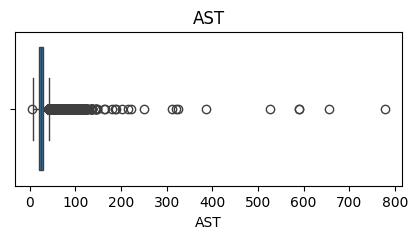

In [7]:
for col in df.columns:
    if col != "smoking":
        plt.figure(figsize=(5,2))
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.show()

### Bivariate Analysis
We study the relationship between each feature and the target variable (smoking). 
This helps identify how different variables vary between smokers and non-smokers.

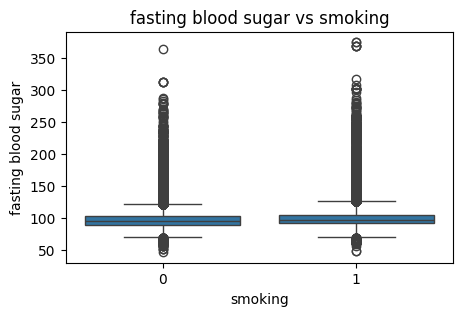

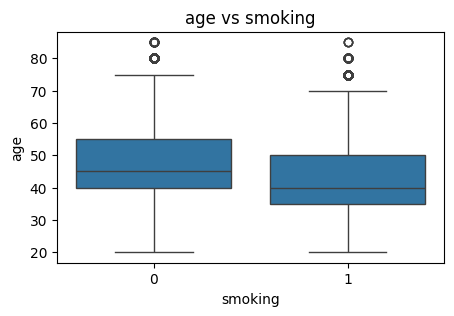

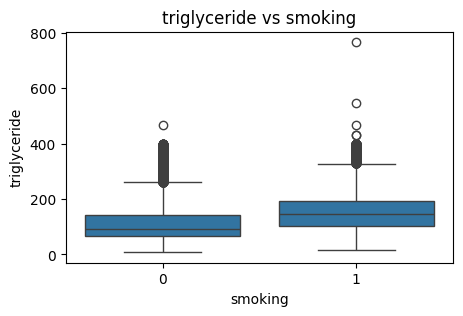

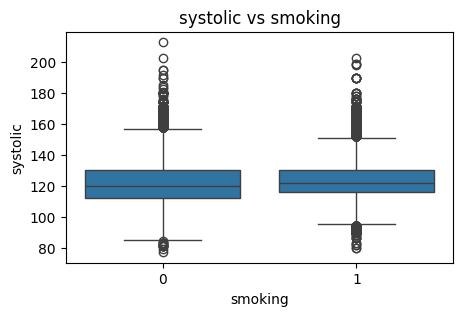

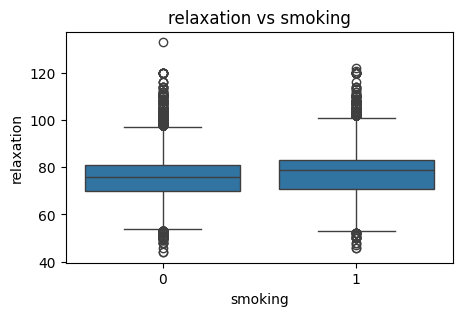

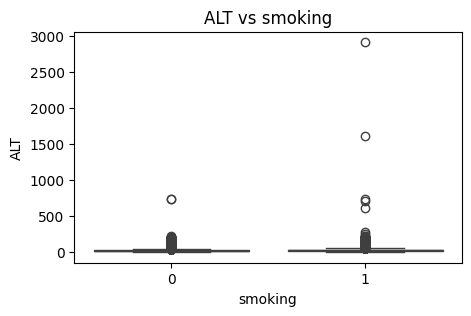

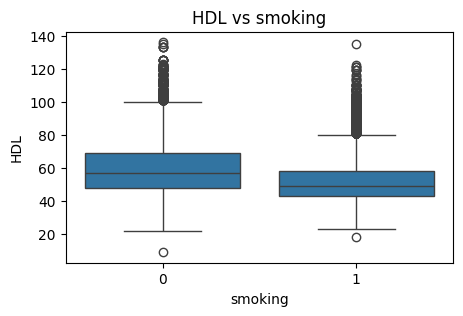

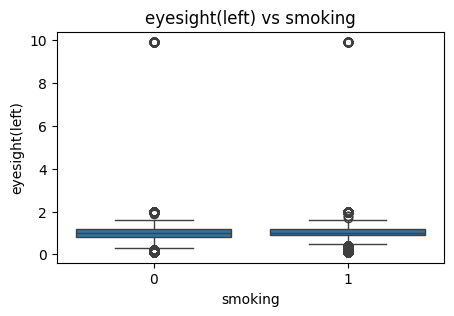

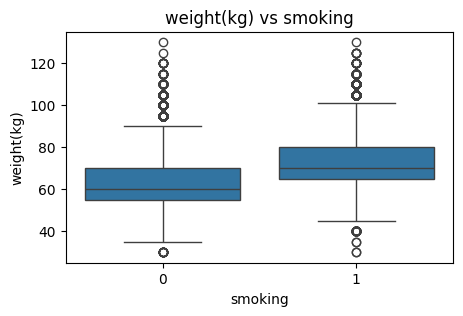

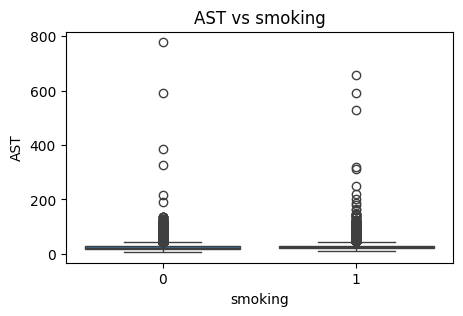

In [8]:
for col in df.columns:
    if col != "smoking":
        plt.figure(figsize=(5,3))
        sns.boxplot(x="smoking", y=col, data=df)
        plt.title(f"{col} vs smoking")
        plt.show()

### Correlation Analysis
A correlation heatmap is used to measure relationships between numerical features. 
It helps identify highly correlated variables that may provide similar information.

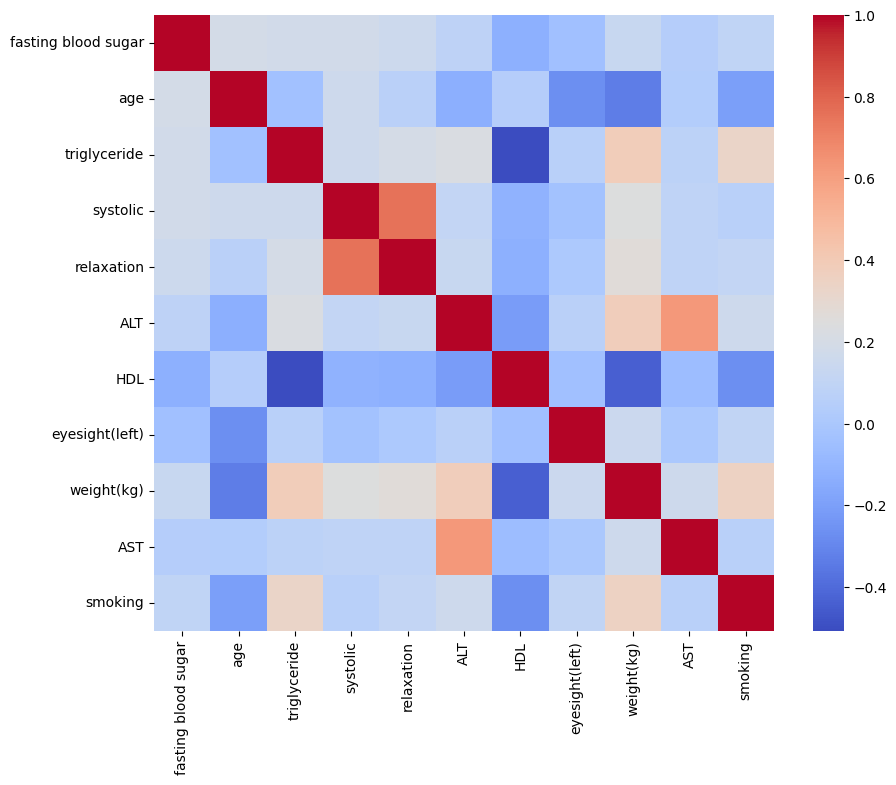

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.show()

### Multivariate Analysis
We use pairplots to visualize relationships between multiple features simultaneously. 
This helps in understanding complex interactions between variables.

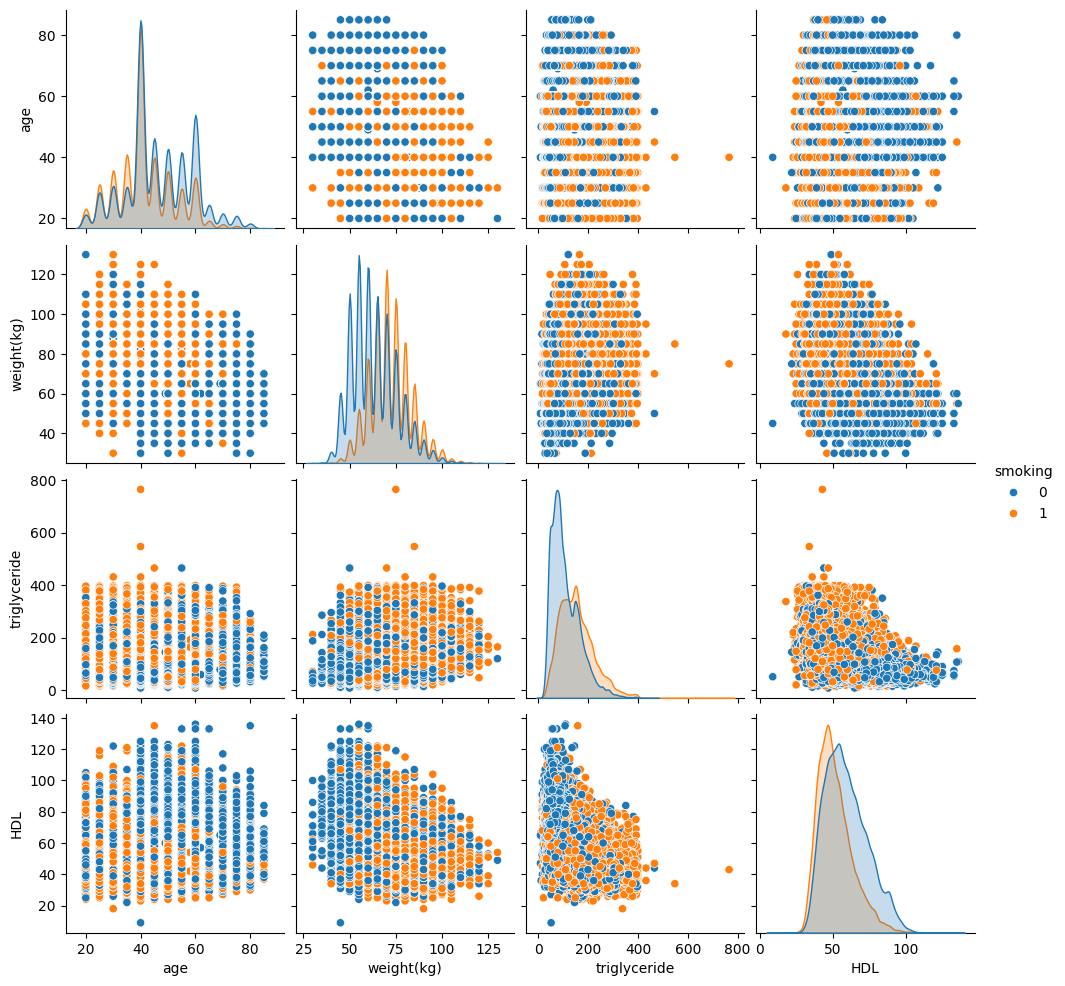

In [10]:
sns.pairplot(df[["age","weight(kg)","triglyceride","HDL","smoking"]],
             hue="smoking")
plt.show()

### Outlier Removal
We apply the IQR method to remove extreme values from the dataset. 
This improves model stability and prevents bias caused by abnormal data points.

In [11]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) |
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [12]:
X = df.drop("smoking", axis=1)
y = df["smoking"]

### Feature Scaling
We apply standardization to normalize feature values to the same scale. 
This ensures that all features contribute equally to the model.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Data Splitting
The dataset is split into training and testing sets. 
The training set is used to build the model, while the testing set is used to evaluate its performance.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

### Logistic Regression Model
A logistic regression model is trained as a simple linear classification approach. 
It models the probability of smoking based on input features.

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Model Evaluation
We evaluate the model using accuracy, precision, recall, and F1-score. 
These metrics help assess the model's classification performance from different perspectives.

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.690803241885773
Precision: 0.649168243848989
Recall: 0.5860084524772952
F1-score: 0.6159735349716446


### Feature Importance
The coefficients of the logistic regression model are analyzed to understand feature importance. 
Positive values increase the likelihood of smoking, while negative values decrease it.

In [17]:

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)
top_features = importance.head(4)["Feature"].tolist()
importance
with open("top_features.json", "w") as f:
    json.dump(top_features, f)